In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
applications = pd.read_csv(
    "../data/applications_cleaned.csv",
    low_memory=False
)
defaults = pd.read_csv("../data/defaults_cleaned.csv")
branches = pd.read_csv("../data/branches_cleaned.csv")

In [3]:
applications['Application_Date'] = pd.to_datetime(
    applications['Application_Date'],
    errors='coerce'
)

defaults['Default_Date'] = pd.to_datetime(
    defaults['Default_Date'],
    errors='coerce'
)

In [4]:
monthly_apps = applications.groupby(
    applications['Application_Date'].dt.to_period('M')
).size()

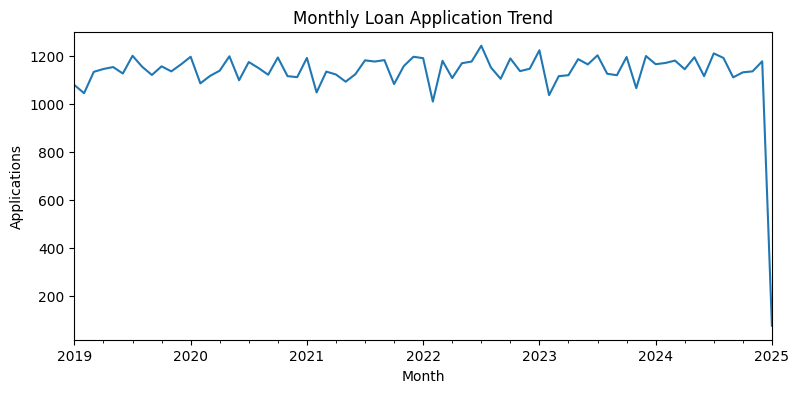

In [5]:
monthly_apps.plot(kind='line', figsize=(9,4))
plt.title("Monthly Loan Application Trend")
plt.xlabel("Month")
plt.ylabel("Applications")
plt.show()

In [6]:
monthly_defaults = defaults.groupby(
    defaults['Default_Date'].dt.to_period('M')
).size()

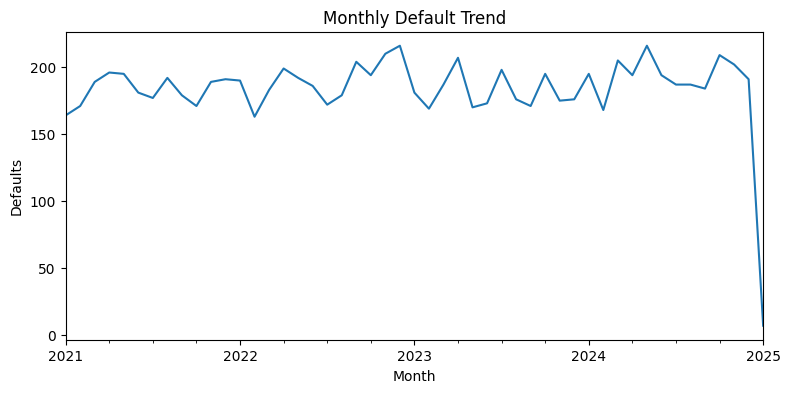

In [7]:
monthly_defaults.plot(kind='line', figsize=(9,4))
plt.title("Monthly Default Trend")
plt.xlabel("Month")
plt.ylabel("Defaults")
plt.show()

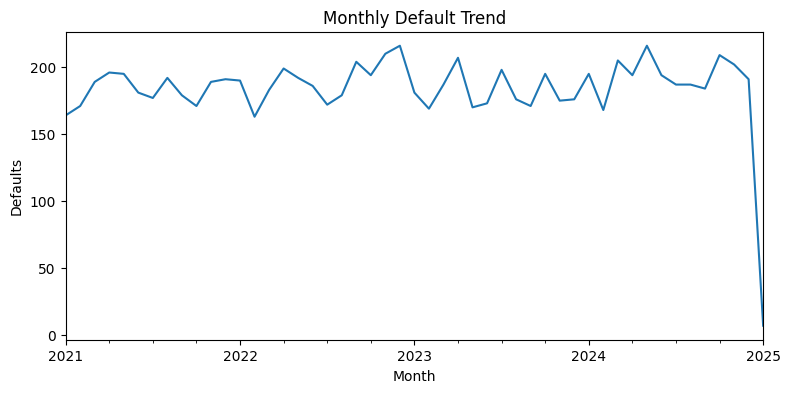

In [8]:
monthly_defaults.plot(kind='line', figsize=(9,4))
plt.title("Monthly Default Trend")
plt.xlabel("Month")
plt.ylabel("Defaults")
plt.show()

In [9]:
ts_compare = pd.concat(
    [monthly_apps, monthly_defaults],
    axis=1
)
ts_compare.columns = ['Applications', 'Defaults']
ts_compare

,Applications,Defaults
2019-01,1079,NaN
2019-02,1045,NaN
2019-03,1134,NaN
2019-04,1146,NaN
2019-05,1154,NaN
...,...,...
2024-09,1111,184.0
2024-10,1132,209.0
2024-11,1136,202.0
2024-12,1178,191.0


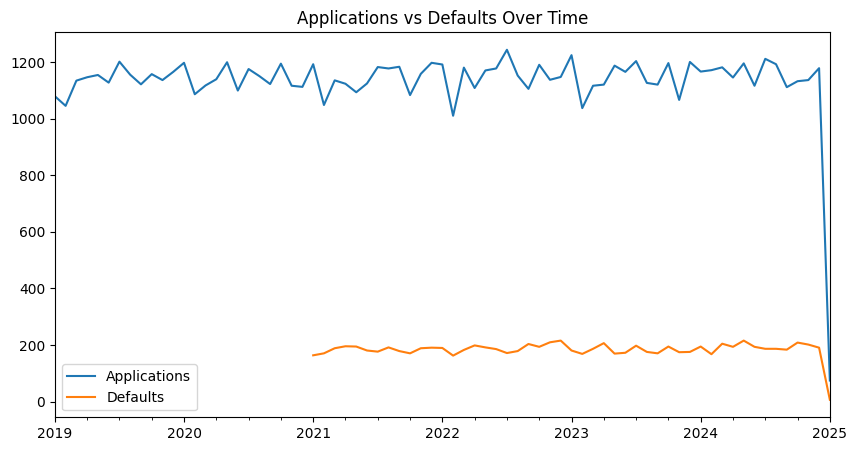

In [10]:
ts_compare.plot(figsize=(10,5))
plt.title("Applications vs Defaults Over Time")
plt.show()

In [11]:
region_default_proxy = branches.groupby('Region')['Delinquent_Loans'].sum()
region_default_proxy

Region
Central       994
East          756
North        1504
Northeast     487
South         846
West          441
Name: Delinquent_Loans, dtype: int64

### Task 16 – Time-Series Insights

- Loan applications display clear monthly fluctuations, indicating seasonality
- Default occurrences follow time-based patterns, often lagging application peaks
- Periods of high application volumes may lead to increased default risk
- Monitoring seasonality can improve capacity planning and risk management